In [12]:
import zipfile

zip_path = "archive (1).zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [13]:
import os

print(os.listdir("dataset"))

['DB']


In [14]:
import os

print(os.listdir("dataset/DB"))

['GT', 'In', 'OUT', 'Res']


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Conv2D, Input, Add
from tensorflow.keras.models import Model
import tensorflow as tf

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [16]:
def add_rician_noise(img, sigma=0.1):
    n1 = np.random.normal(0, sigma, img.shape)
    n2 = np.random.normal(0, sigma, img.shape)
    noisy = np.sqrt((img + n1)**2 + n2**2)
    return np.clip(noisy, 0, 1)

In [17]:
input_path = "dataset/DB/In"
gt_path = "dataset/DB/GT"

noisy_images = []
clean_images = []

# Sort files to keep consistent pairing
files = sorted(os.listdir(gt_path))

for file in files:
    gt_file = os.path.join(gt_path, file)
    
    # Skip non-image files (safety)
    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # Load clean image (GT)
    clean_img = load_img(gt_file, color_mode='grayscale', target_size=(256, 256))
    clean_img = img_to_array(clean_img) / 255.0

    # Add Rician noise
    noisy_img = add_rician_noise(clean_img)

    noisy_images.append(noisy_img)
    clean_images.append(clean_img)

# Convert to numpy arrays
noisy_images = np.array(noisy_images, dtype=np.float32)
clean_images = np.array(clean_images, dtype=np.float32)

print("Shapes:", noisy_images.shape, clean_images.shape)

Shapes: (50, 256, 256, 1) (50, 256, 256, 1)


In [18]:
from tensorflow.keras.layers import Conv2D, Input, Add
from tensorflow.keras.models import Model

input_img = Input(shape=(256, 256, 1))

x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Conv2D(64, (3,3), padding='same')(x)
x = Conv2D(1, (3,3), padding='same')(x)

# Residual learning
output = Add()([input_img, -x])

model = Model(inputs=input_img, outputs=output)

In [19]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.5 * mse + 0.5 * (1 - ssim)

In [20]:
model.compile(optimizer='adam', loss=combined_loss)

history = model.fit(
    noisy_images, clean_images,
    batch_size=8,
    epochs=50,
    validation_split=0.1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - loss: 0.3025 - val_loss: 0.2109
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.1805 - val_loss: 0.1692
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 0.1674 - val_loss: 0.1276
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.1517 - val_loss: 0.1338
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.1352 - val_loss: 0.1305
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.1277 - val_loss: 0.1263
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - loss: 0.1248 - val_loss: 0.1121
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - loss: 0.1135 - val_loss: 0.1030
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - loss: 0.1061 - val_loss: 0.0966
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - loss: 0.1066 - val_loss: 0.0910
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.1033 - val_loss: 0.0874
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - loss: 0.1026 - val_loss: 0.0848
Epoch 13/50
6

In [21]:
def evaluate(original, denoised):
    psnr = peak_signal_noise_ratio(original, denoised, data_range=1.0)
    ssim = structural_similarity(
        original.squeeze(),
        denoised.squeeze(),
        data_range=1.0   
    )
    rmse = np.sqrt(np.mean((original - denoised)**2))
    return psnr, ssim, rmse

In [22]:
def enhance_image(img):
    img = img.squeeze()
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step

--- Image 0 ---
PSNR: 29.052421228745068
SSIM: 0.8824612794669318
RMSE: 0.035267845


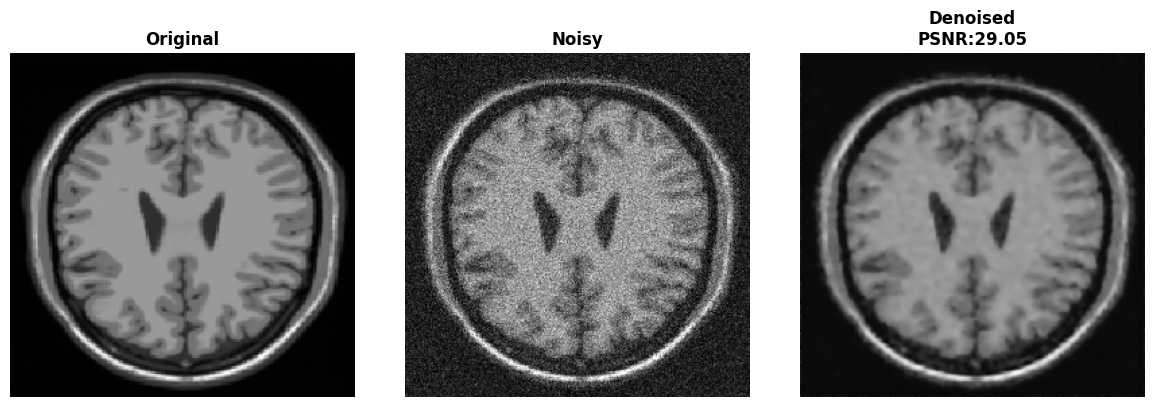

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

--- Image 1 ---
PSNR: 29.041684058958282
SSIM: 0.8813391799216121
RMSE: 0.03531147


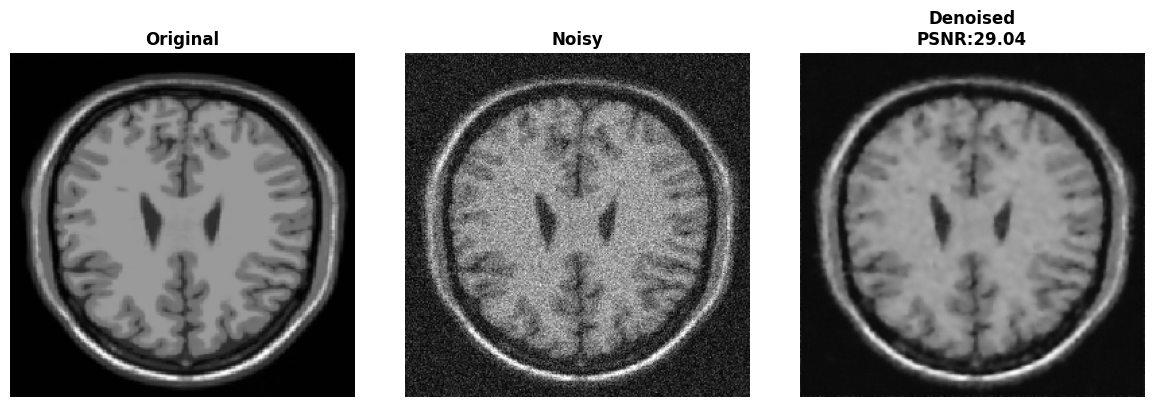

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step

--- Image 2 ---
PSNR: 29.18762968109411
SSIM: 0.883188958103478
RMSE: 0.034723103


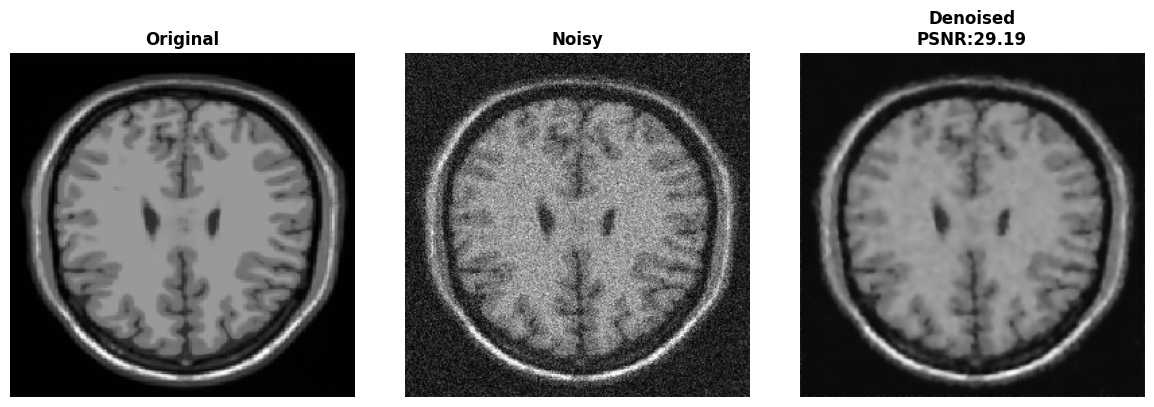

In [23]:
for idx in range(3):
    denoised = model.predict(noisy_images[idx:idx+1])[0]
    
    psnr, ssim, rmse = evaluate(clean_images[idx], denoised)
    
    print(f"\n--- Image {idx} ---")
    print("PSNR:", psnr)
    print("SSIM:", ssim)
    print("RMSE:", rmse)

    plt.figure(figsize=(12,4))

    # ORIGINAL
    plt.subplot(1,3,1)
    plt.title("Original", fontsize=12, fontweight='bold')
    plt.imshow(enhance_image(clean_images[idx]), cmap='gray')
    plt.axis('off')

    # NOISY 
    plt.subplot(1,3,2)
    plt.title("Noisy", fontsize=12, fontweight='bold')
    plt.imshow(enhance_image(noisy_images[idx]), cmap='gray')
    plt.axis('off')

    # DENOISED 
    plt.subplot(1,3,3)
    plt.title(f"Denoised\nPSNR:{psnr:.2f}", fontsize=12, fontweight='bold')
    plt.imshow(enhance_image(denoised), cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

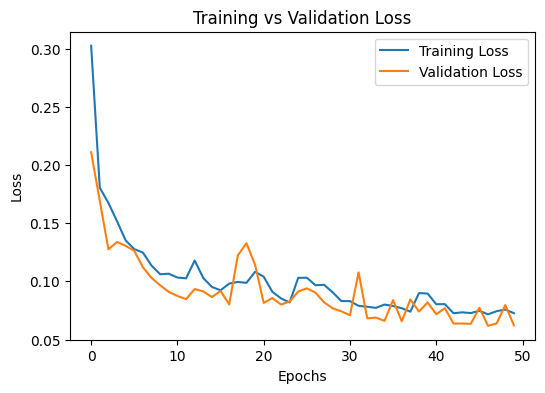

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [25]:
plt.imsave("denoised_output.png", denoised.squeeze(), cmap='gray')

In [26]:
psnr_list = []
ssim_list = []
rmse_list = []

for idx in range(len(noisy_images)):
    denoised = model.predict(noisy_images[idx:idx+1])
    
    psnr, ssim, rmse = evaluate(clean_images[idx], denoised[0])
    
    psnr_list.append(psnr)
    ssim_list.append(ssim)
    rmse_list.append(rmse)

print("Average PSNR:", sum(psnr_list)/len(psnr_list))
print("Average SSIM:", sum(ssim_list)/len(ssim_list))
print("Average RMSE:", sum(rmse_list)/len(rmse_list))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 